# Extração e medida de desalinhamento do BAG

Implementação do artigo:
[1] T. Nikoukhah, J. Anger, M. Colom, J.-M. Morel, e R. Grompone Von Gioi, “ZERO: a Local JPEG Grid Origin Detector Based on the Number of DCT Zeros and its Applications in Image Forensics”, Image Processing On Line, vol. 11, p. 396–433, dez. 2021, doi: 10.5201/ipol.2021.390.
5.

Autor: Paulo Max Gil Innocencio Reis

Email: paulo.pmgir@pf.gov.br

Serviço de Perícias em Audiovisual e Eletrônicos - INC/DITEC

*Edições podem deixar criar desalinhamentos no BAG, ou . Detecção de grid por meio do algoritmo ZEROperturbá-lo

## Carrega pacotes e biblioteca libzero.so

In [1]:
!pip install iio --proxy http://proxy.ditec.pf.gov.br:3128

Defaulting to user installation because normal site-packages is not writeable
  Using cached iio-29.tar.gz (55 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for iio (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [14 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build/lib.linux-x86_64-cpython-310
      copying iio.py -> build/lib.linux-x86_64-cpython-310
      running build_ext
      building 'libiio' extension
      creating build/temp.linux-x86_64-cpython-310/iio
      gcc -pthread -B /opt/tljh/user/compiler_compat -Wno-unused-result -Wsign-compare -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /opt/tljh/user/include -fPIC -O2 -isystem /opt/tljh/user/include -fPIC -Iiio -I/usr/local/include -I/opt/tljh/user/include/python3.10 -c iio/iio.c -o build/temp.linux-x86_

In [2]:
conda install -c conda-forge iio

Solving environment: failed with initial frozen solve. Retrying with flexible solve.
Solving environment: failed with initial frozen solve. Retrying with flexible solve.

PackagesNotFoundError: The following packages are not available from current channels:

  - iio

Current channels:

  - https://conda.anaconda.org/conda-forge/linux-64
  - https://conda.anaconda.org/conda-forge/noarch

To search for alternate channels that may provide the conda package you're
looking for, navigate to

    https://anaconda.org

and use the search bar at the top of the page.



Note: you may need to restart the kernel to use updated packages.


In [1]:
import iio
import cffi
import numpy as np
import matplotlib.pyplot as plt
# from skimage.util import view_as_blocks
import scipy as sp
# import sys
# import scipy.fft
import os

ffi = cffi.FFI()
ffi.cdef('''
void rgb2luminance(double * input, double * output, int X, int Y, int C);
void compute_grid_votes_per_pixel(double * image, int * votes, int X, int Y);
int detect_global_grids(int * votes, double * lnfa_grids, int X, int Y);
typedef struct {
    int x0, y0, x1, y1;
    int grid;
    double lnfa;
} meaningful_reg;
int detect_forgeries(int * votes, int * forgery_mask, int * forgery_mask_reg,
                     meaningful_reg * forged_regions,
                     int X, int Y, int grid_to_exclude, int grid_max);
''')

libzero = ffi.dlopen('./libzero.so_')

cmap1 = plt.get_cmap('tab20')
cmap2 = plt.get_cmap('tab20b')
cmap3 = plt.get_cmap('tab20c')
cmap4 = plt.get_cmap('Set3')

AttributeError: /opt/tljh/user/bin/python: undefined symbol: iio_get_backends_count

## Carrega imagem de trabalho

In [171]:
filename = 'DSC_0864.png'

## Defiição de funções auxiliares

In [172]:
def colormap(v):
    v = v.copy()
    # swap 0 and 4 so that 0 is colored with green
    v0 = v == 0
    v4 = v == 4
    v[v0] = 4
    v[v4] = 0
    v2 = cmap1(v/20)
    v2[v >= 20] = cmap2((v[v >= 20] - 20)/20)
    v2[v >= 40] = cmap3((v[v >= 40] - 40)/20)
    v2[v >= 60] = cmap4((v[v >= 60] - 60)/20)
    return v2

def P(array):
    typestr = 'double*'
    if array.dtype == np.float32:
        typestr = 'float*'
    elif array.dtype == bool:
        typestr = 'bool*'
    elif array.dtype == np.int32:
        typestr = 'int*'
    # requires cffi 0.12
    return ffi.from_buffer(typestr, array, require_writable=True)



## Executa a extração do grid por meio do algoritmo ZERO



In [173]:
image = iio.read(filename).astype(np.float64)
h, w, c = image.shape
image = image.transpose((2, 0, 1))
image = image.copy(order='C')

print('1. convert to luminance\n')
im = np.zeros((h,w), dtype=np.float64)
im = im.copy(order='C')

libzero.rgb2luminance(P(image), P(im), w, h, c)
#iio.write('luminance.png', im)

# intermediate step before statistical validation
print('2. compute vote map\n')
votes = np.zeros(im.shape, dtype=np.int32)
libzero.compute_grid_votes_per_pixel(P(im), P(votes), w, h)

print('2bis. color vote map\n')
colored_votes = 255 * colormap(votes)[...,:3]
colored_votes[votes == -1] = 0
colored_votes = colored_votes.astype(np.uint8)
colored_votes1 = colored_votes


# one color per grid origin + black in case of a tie
#iio.write('colored_votemap.png', colored_votes)

print('3. detect global grids\n')
lnfa_grids = np.zeros((8, 8), dtype=np.float64)
main_grid = libzero.detect_global_grids(P(votes), P(lnfa_grids), w, h)
significant_grids = np.where(lnfa_grids < 0.0)

if main_grid == -1:
    print('No overall JPEG grid found') # this means the image has no detectable JPEG traces
else:
    print("main grid is " + str(main_grid%8) + "," + str(int(main_grid/8)) )

if main_grid > 0:
    print('The most meaningful JPEG grid origin is not (0,0).\n'
           'This may indicate that the image has been cropped.\n') # this means that the grid is not aligned

for i in range(64):
    if lnfa_grids[int(i/8)][i%8] < 0.0:
        print("significant grid is "+ str(i%8) + "," + str(int(i/8))
              + " with log(nfa) = " + str(lnfa_grids[int(i/8)][i%8]))

print('\n4. detect forgeries\n')
forgery = np.zeros(im.shape, dtype=np.int32)
forgery_c = np.zeros(im.shape, dtype=np.int32)
forgery_result = np.zeros(im.shape, dtype=np.int32)

forged_region = ffi.new('meaningful_reg[]', w*h)
forgery_found = libzero.detect_forgeries(P(votes), P(forgery), P(forgery_c),
                                         forged_region, w, h, main_grid, 63)

if forgery_found > 0:
    for i in range(forgery_found):
        print("foreign grid was found here: " + str(forged_region[i].x0) + " "
              + str(forged_region[i].y0) + " - " + str(forged_region[i].x1) + " "
              + str(forged_region[i].y1))
        print("grid is " + str(forged_region[i].grid%8) + ","
              + str(int(forged_region[i].grid/8))
              + " with log(nfa) = " + str(forged_region[i].lnfa))

forgery_result = forgery_c

# do the rest only if main grid is detected
if main_grid > -1:
    print('\n5. create simulated version\n')

    # create JPEG file with PIL
    ######################################################
    from PIL import Image
    pil_image = Image.open(filename)
    pil_image = pil_image.convert('RGB')  # Convert to RGB mode
    pil_image.save('version99.jpg', format='JPEG', quality=99)
    pil_image = iio.read('version99.jpg').astype(np.float64)

    ######################################################

    h, w, c  = pil_image.shape
    pil_image  = pil_image.transpose((2, 0, 1))
    pil_image = pil_image.copy(order='C')

    img = np.zeros((h,w), dtype=np.float64)
    img = img.copy(order='C')

    libzero.rgb2luminance(P(pil_image), P(img), w, h, c)

    votes2 = np.zeros(img.shape, dtype=np.int32)
    libzero.compute_grid_votes_per_pixel(P(img), P(votes2), w, h)
    votes3=votes2

  #  iio.write('votes2.png', votes2)

    nb_globalgrids = len(np.where(lnfa_grids<0)[0])
    for i in range(nb_globalgrids):
        x = np.where(lnfa_grids<0)[0][i]
        y = np.where(lnfa_grids<0)[1][i]
        coordgrid = x*8+y
        votes2[votes == coordgrid] = -1

    print('2bis. color vote map\n')
    colored_votes = 255 * colormap(votes2)[...,:3]
    colored_votes[votes2 == -1] = 0
    colored_votes = colored_votes.astype(np.uint8)

    # one color per grid origin + black in case of a tie
 #   iio.write('colored_votemap_new.png', colored_votes)
    colored_votes_new = colored_votes


    print('\n5. detect suspicious areas\n')
    forgery = np.zeros(img.shape, dtype=np.int32)
    forgery_c2 = np.zeros(img.shape, dtype=np.int32)
    forged_region = ffi.new('meaningful_reg[]', w*h)

    forgery_found2 = libzero.detect_forgeries(P(votes2), P(forgery), P(forgery_c2),
                                              forged_region, w, h, -1, 0)

    if forgery_found2 > 0:
        for i in range(forgery_found2):
            print("an absence of grid was found here: " + str(forged_region[i].x0) + " "
                  + str(forged_region[i].y0) + " - " + str(forged_region[i].x1) + " "
                  + str(forged_region[i].y1))
            print("with log(nfa) = " + str(forged_region[i].lnfa))
            forgery = forgery_c  + 0.5*forgery_c2
            forgery_result = np.clip(forgery, 0, 255)

#iio.write('result_zero.png', forgery_result) # all black if no forgeries

print('\nok')

libpng warning: iCCP: known incorrect sRGB profile


1. convert to luminance

2. compute vote map

2bis. color vote map

3. detect global grids

No overall JPEG grid found

4. detect forgeries


ok


## Plotagem das funções dos mapas de grid de máscaras de detecção

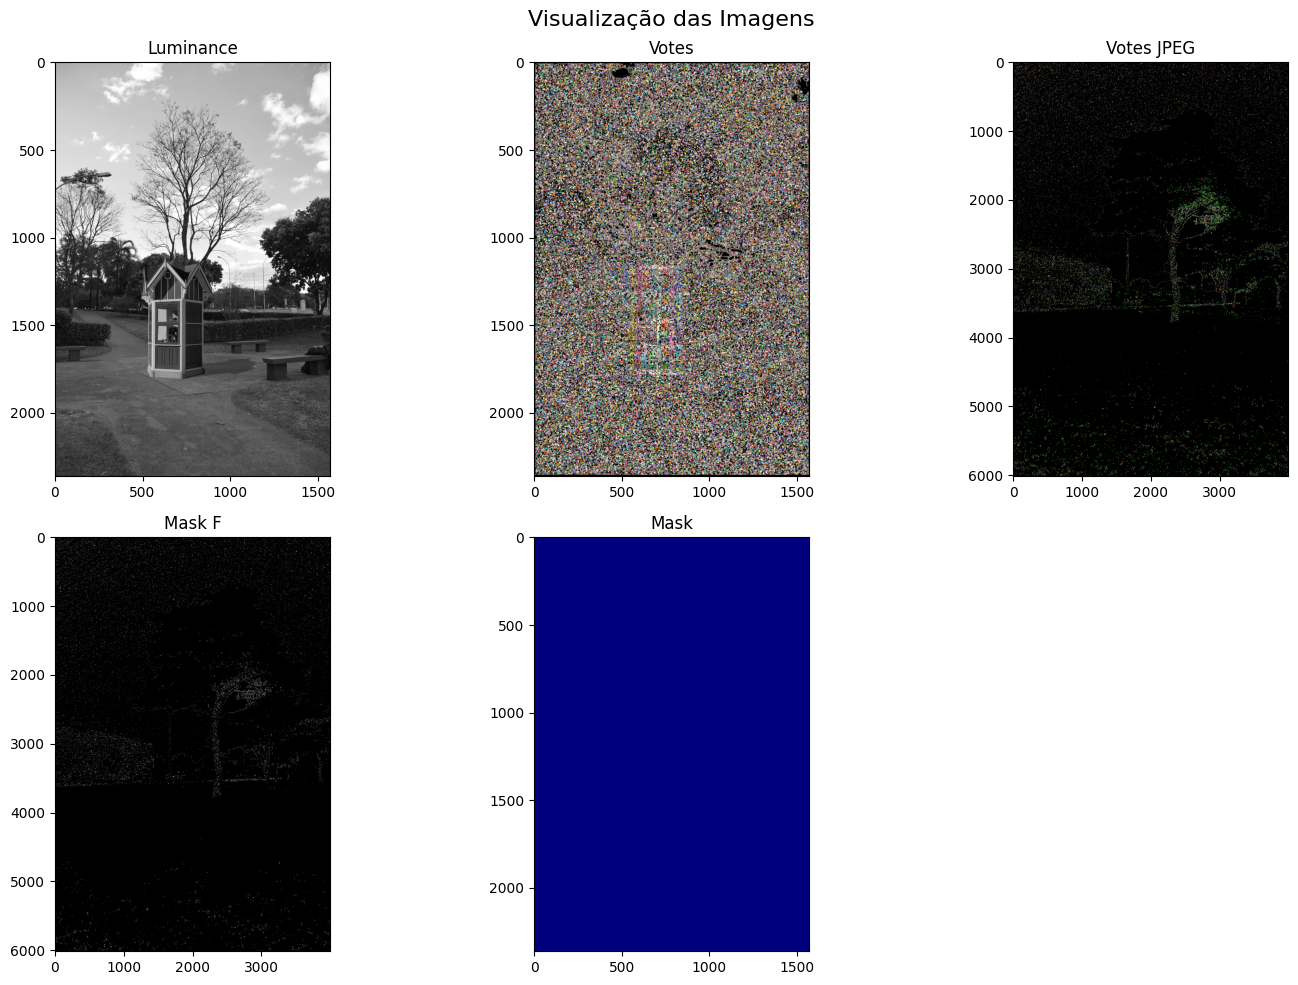

In [174]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Visualização das Imagens", fontsize=16)
axs = axs.ravel()

axs[0].imshow(im, cmap='gray')
axs[0].set_title('Luminance')
axs[1].imshow(colored_votes)
axs[1].set_title('Votes')
axs[2].imshow(colored_votes_new)
axs[2].set_title('Votes JPEG')
axs[3].imshow(votes3, cmap='gray')
axs[3].set_title('Mask F')
axs[4].imshow(forgery_result, cmap='jet')
axs[4].set_title('Mask')
fig.delaxes(axs[5])
#for ax in axs[:5]:
#    plt.colorbar(ax.images[0], ax=ax)

# Ajustar o layout e mostrar o plot
plt.tight_layout()
plt.show()

In [176]:

iio.write('colored_votemap.png', colored_votes1)
iio.write('result_zero.png', forgery_result) # all black if no forgeries


